# Day 10: Final-Temperature Bucket Pricing Layer

This notebook documents the reusable Day 10 layer for converting final-temperature market buckets into forecast-error intervals and pricing those buckets from any model-provided CDF.

The central project rule is:

```text
forecast_error = actual official high - NWS forecast high
```

So a final-temperature market bucket written as:

```text
lower_temp < actual_high <= upper_temp
```

becomes this forecast-error interval:

```text
lower_temp - forecast_high < forecast_error <= upper_temp - forecast_high
```

The layer is model-agnostic. It does not know whether the CDF came from an empirical model, NGBoost, a cumulative classifier, quantile interpolation, or a hand-built distribution.

## What Day 10 Created

| File | Purpose |
| --- | --- |
| `src/bucket_schema.py` | Adds `TemperatureBucket`, integer final-temperature buckets, and contiguous bucket validation. |
| `src/interval_probs.py` | Adds callable-CDF interval probabilities and list probability normalization. |
| `src/distribution_pricing.py` | Adds `ErrorBucket`, temperature-to-error conversion, and model-agnostic pricing from any CDF. |
| `scripts/generate_day10_distribution_pricing_outputs.py` | Recreates the Day 10 example CSV outputs. |
| `tests/test_day10_distribution_pricing.py` | Tests bucket construction, conversion, interval probability math, normalization, and generated outputs. |
| `outputs/forecast_error_bucket_conversion_examples.csv` | The worked forecast_high=73 conversion example. |
| `outputs/interval_probability_demo.csv` | A normal-CDF probability demo over the same buckets. |

## Import Setup

Run this first. It makes the notebook work whether it is opened from the repo root or from inside `notebooks/`.

In [1]:
from __future__ import annotations

from math import erf, sqrt
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "src").exists() else cwd.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

OUTPUT_DIR = repo_root / "outputs"

from src.bucket_schema import (
    TemperatureBucket,
    format_bucket_interval,
    make_integer_temperature_buckets,
    validate_temperature_buckets,
)
from src.interval_probs import interval_probability, normalize_probabilities
from src.distribution_pricing import (
    convert_temperature_buckets_to_error_buckets,
    price_temperature_buckets_from_cdf,
    temperature_bucket_to_error_bucket,
)
from scripts.generate_day10_distribution_pricing_outputs import (
    generate_forecast_error_bucket_conversion_examples,
    generate_interval_probability_demo,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.6f}".format

repo_root

WindowsPath('C:/Weather Trading/Kalshi-Weather-Trading')

## 1. Final-Temperature Bucket Schema

`TemperatureBucket` is the new clean schema for final-temperature markets:

```python
TemperatureBucket(
    label: str,
    lower_temp: float | None,
    upper_temp: float | None,
)
```

Every bucket follows the same settlement convention:

```text
lower_temp < actual_high <= upper_temp
```

`None` means the interval is open-ended. A lower `None` means negative infinity, and an upper `None` means positive infinity.

In [2]:
buckets = make_integer_temperature_buckets(71, 76)

bucket_rows = [
    {
        "bucket": bucket.label,
        "lower_temp": bucket.lower_temp,
        "upper_temp": bucket.upper_temp,
        "interval_text": format_bucket_interval(bucket),
    }
    for bucket in buckets
]

pd.DataFrame(bucket_rows)

,bucket,lower_temp,upper_temp,interval_text
0,71 or lower,NaN,71.500000,actual <= 71.5
1,72,71.500000,72.500000,71.5 < actual <= 72.5
2,73,72.500000,73.500000,72.5 < actual <= 73.5
3,74,73.500000,74.500000,73.5 < actual <= 74.5
4,75,74.500000,75.500000,74.5 < actual <= 75.5
5,76 or higher,75.500000,NaN,actual > 75.5


The integer bucket builder uses half-degree boundaries. That matters because an integer official high settles into exactly one bucket:

- `72` means `71.5 < actual_high <= 72.5`
- `73` means `72.5 < actual_high <= 73.5`
- `76 or higher` means `actual_high > 75.5`

This avoids the off-by-one mistake of using integer boundaries like `72 < actual <= 73`.

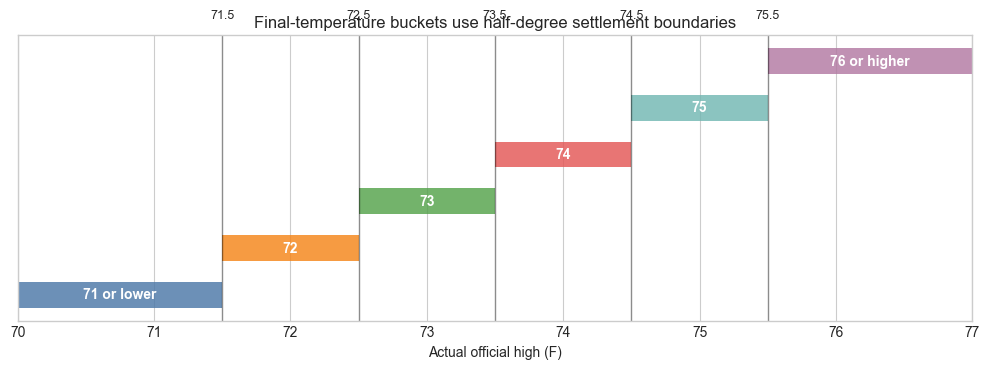

In [3]:
def finite_or_axis(value: float | None, fallback: float) -> float:
    return fallback if value is None else float(value)


fig, ax = plt.subplots(figsize=(10, 3.8))
x_min, x_max = 70.0, 77.0

colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2"]
for y, (bucket, color) in enumerate(zip(buckets, colors)):
    left = finite_or_axis(bucket.lower_temp, x_min)
    right = finite_or_axis(bucket.upper_temp, x_max)
    ax.barh(y, right - left, left=left, height=0.55, color=color, alpha=0.82)
    ax.text((left + right) / 2, y, bucket.label, ha="center", va="center", color="white", weight="bold")

for boundary in [71.5, 72.5, 73.5, 74.5, 75.5]:
    ax.axvline(boundary, color="black", linewidth=1, alpha=0.45)
    ax.text(boundary, len(buckets) - 0.15, f"{boundary:g}", ha="center", va="bottom", fontsize=9)

ax.set_xlim(x_min, x_max)
ax.set_yticks([])
ax.set_xlabel("Actual official high (F)")
ax.set_title("Final-temperature buckets use half-degree settlement boundaries")
plt.tight_layout()

## 2. Convert Final-Temperature Buckets To Forecast-Error Buckets

The conversion is intentionally simple. For each finite temperature boundary, subtract `forecast_high`.

For `forecast_high = 73`:

| Temperature bucket | Forecast-error bucket |
| --- | --- |
| `actual_high <= 71.5` | `error <= -1.5` |
| `71.5 < actual_high <= 72.5` | `-1.5 < error <= -0.5` |
| `72.5 < actual_high <= 73.5` | `-0.5 < error <= 0.5` |
| `73.5 < actual_high <= 74.5` | `0.5 < error <= 1.5` |
| `74.5 < actual_high <= 75.5` | `1.5 < error <= 2.5` |
| `actual_high > 75.5` | `error > 2.5` |

In [4]:
forecast_high = 73.0
error_buckets = convert_temperature_buckets_to_error_buckets(buckets, forecast_high=forecast_high)

conversion_rows = []
for bucket, error_bucket in zip(buckets, error_buckets):
    conversion_rows.append(
        {
            "bucket": bucket.label,
            "lower_temp": bucket.lower_temp,
            "upper_temp": bucket.upper_temp,
            "forecast_high": forecast_high,
            "lower_error": error_bucket.lower_error,
            "upper_error": error_bucket.upper_error,
        }
    )

conversion_df = pd.DataFrame(conversion_rows)
conversion_df

,bucket,lower_temp,upper_temp,forecast_high,lower_error,upper_error
0,71 or lower,NaN,71.500000,73.000000,NaN,-1.500000
1,72,71.500000,72.500000,73.000000,-1.500000,-0.500000
2,73,72.500000,73.500000,73.000000,-0.500000,0.500000
3,74,73.500000,74.500000,73.000000,0.500000,1.500000
4,75,74.500000,75.500000,73.000000,1.500000,2.500000
5,76 or higher,75.500000,NaN,73.000000,2.500000,NaN


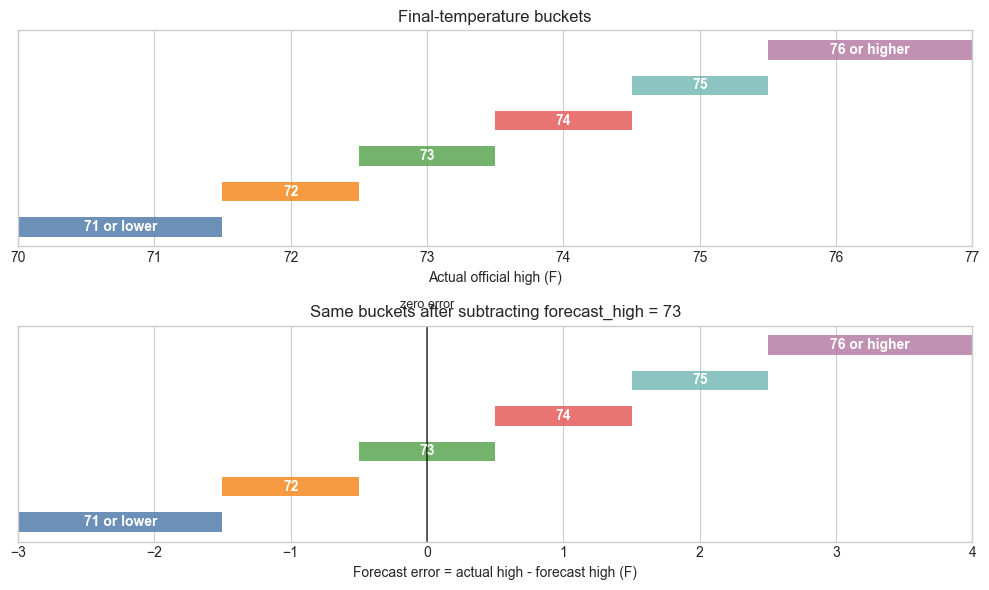

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)

for y, (bucket, color) in enumerate(zip(buckets, colors)):
    left = finite_or_axis(bucket.lower_temp, 70.0)
    right = finite_or_axis(bucket.upper_temp, 77.0)
    axes[0].barh(y, right - left, left=left, height=0.55, color=color, alpha=0.82)
    axes[0].text((left + right) / 2, y, bucket.label, ha="center", va="center", color="white", weight="bold")

for y, (error_bucket, color) in enumerate(zip(error_buckets, colors)):
    left = finite_or_axis(error_bucket.lower_error, -3.0)
    right = finite_or_axis(error_bucket.upper_error, 4.0)
    axes[1].barh(y, right - left, left=left, height=0.55, color=color, alpha=0.82)
    axes[1].text((left + right) / 2, y, error_bucket.label, ha="center", va="center", color="white", weight="bold")

for ax, xlabel, title in [
    (axes[0], "Actual official high (F)", "Final-temperature buckets"),
    (axes[1], "Forecast error = actual high - forecast high (F)", "Same buckets after subtracting forecast_high = 73"),
]:
    ax.set_yticks([])
    ax.set_xlabel(xlabel)
    ax.set_title(title)

axes[0].set_xlim(70.0, 77.0)
axes[1].set_xlim(-3.0, 4.0)
axes[1].axvline(0.0, color="black", linewidth=1.2, alpha=0.7)
axes[1].text(0.0, len(error_buckets) - 0.05, "zero error", ha="center", va="bottom", fontsize=9)

plt.tight_layout()

## 3. Callable-CDF Interval Probability

`interval_probability(cdf, lower, upper)` computes probability mass using:

```text
P(a < error <= b) = F(b) - F(a)
```

Open-ended intervals use the limiting CDF values:

- `lower=None` means `F(-inf) = 0`
- `upper=None` means `F(+inf) = 1`
- both `None` means the interval covers everything, so probability is `1`

The helper validates finite boundaries, finite CDF outputs, CDF values in `[0, 1]`, and nonnegative interval mass.

In [6]:
def fake_cdf(x: float) -> float:
    return float(x)


fake_examples = [
    {"interval": "0.2 < error <= 0.7", "probability": interval_probability(fake_cdf, 0.2, 0.7)},
    {"interval": "error <= 0.7", "probability": interval_probability(fake_cdf, None, 0.7)},
    {"interval": "error > 0.2", "probability": interval_probability(fake_cdf, 0.2, None)},
    {"interval": "all errors", "probability": interval_probability(fake_cdf, None, None)},
]

pd.DataFrame(fake_examples)

,interval,probability
0,0.2 < error <= 0.7,0.500000
1,error <= 0.7,0.700000
2,error > 0.2,0.800000
3,all errors,1.000000


## 4. Normal CDF Probability Demo

For the output demo, Day 10 uses a simple normal CDF centered at zero forecast error:

```text
mu = 0.0
sigma = 1.5
```

This is only a worked example. The production pricing function accepts any callable CDF with the same signature: `cdf(x: float) -> float`.

In [7]:
def normal_error_cdf(x: float, mu: float = 0.0, sigma: float = 1.5) -> float:
    if sigma <= 0.0:
        raise ValueError("sigma must be greater than 0")
    z = (float(x) - mu) / (sigma * sqrt(2.0))
    return float(0.5 * (1.0 + erf(z)))


priced_rows = price_temperature_buckets_from_cdf(
    buckets=buckets,
    forecast_high=forecast_high,
    cdf=lambda x: normal_error_cdf(x, mu=0.0, sigma=1.5),
    normalize=True,
)

priced_df = pd.DataFrame(priced_rows)
priced_df

,bucket,lower_temp,upper_temp,forecast_high,lower_error,upper_error,probability
0,71 or lower,NaN,71.500000,73.000000,NaN,-1.500000,0.158655
1,72,71.500000,72.500000,73.000000,-1.500000,-0.500000,0.210786
2,73,72.500000,73.500000,73.000000,-0.500000,0.500000,0.261117
3,74,73.500000,74.500000,73.000000,0.500000,1.500000,0.210786
4,75,74.500000,75.500000,73.000000,1.500000,2.500000,0.110865
5,76 or higher,75.500000,NaN,73.000000,2.500000,NaN,0.047790


In [8]:
probability_sum = priced_df["probability"].sum()
center_bucket = priced_df.loc[priced_df["probability"].idxmax(), "bucket"]
symmetry_gap = abs(
    float(priced_df.loc[priced_df["bucket"] == "72", "probability"].iloc[0])
    - float(priced_df.loc[priced_df["bucket"] == "74", "probability"].iloc[0])
)

pd.DataFrame(
    [
        {"check": "probabilities sum to one", "value": probability_sum},
        {"check": "highest-probability bucket", "value": center_bucket},
        {"check": "absolute 72-vs-74 probability gap", "value": symmetry_gap},
        {"check": "minimum probability", "value": priced_df["probability"].min()},
    ]
)

,check,value
0,probabilities sum to one,1.000000
1,highest-probability bucket,73
2,absolute 72-vs-74 probability gap,0.000000
3,minimum probability,0.047790


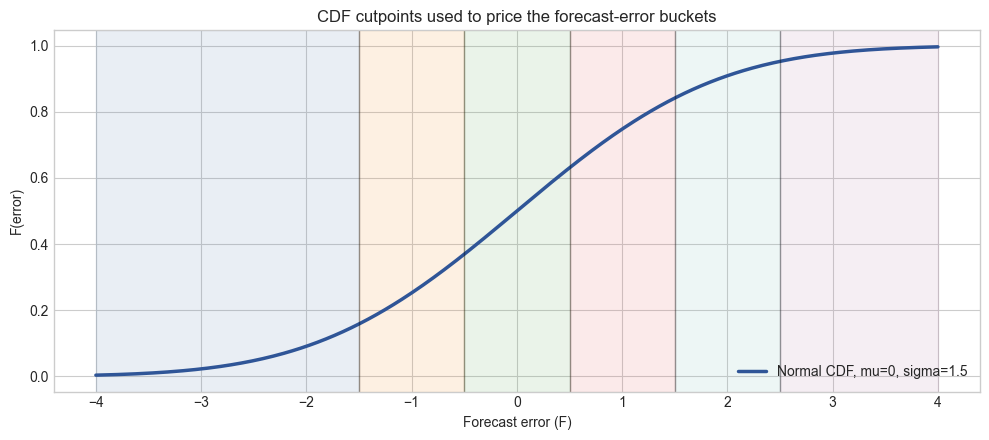

In [9]:
x = np.linspace(-4.0, 4.0, 400)
cdf_y = [normal_error_cdf(value) for value in x]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(x, cdf_y, color="#2F5597", linewidth=2.5, label="Normal CDF, mu=0, sigma=1.5")

for error_bucket, color in zip(error_buckets, colors):
    left = finite_or_axis(error_bucket.lower_error, x.min())
    right = finite_or_axis(error_bucket.upper_error, x.max())
    ax.axvspan(left, right, color=color, alpha=0.12)

for boundary in [-1.5, -0.5, 0.5, 1.5, 2.5]:
    ax.axvline(boundary, color="black", linewidth=1, alpha=0.35)

ax.set_title("CDF cutpoints used to price the forecast-error buckets")
ax.set_xlabel("Forecast error (F)")
ax.set_ylabel("F(error)")
ax.legend(loc="lower right")
plt.tight_layout()

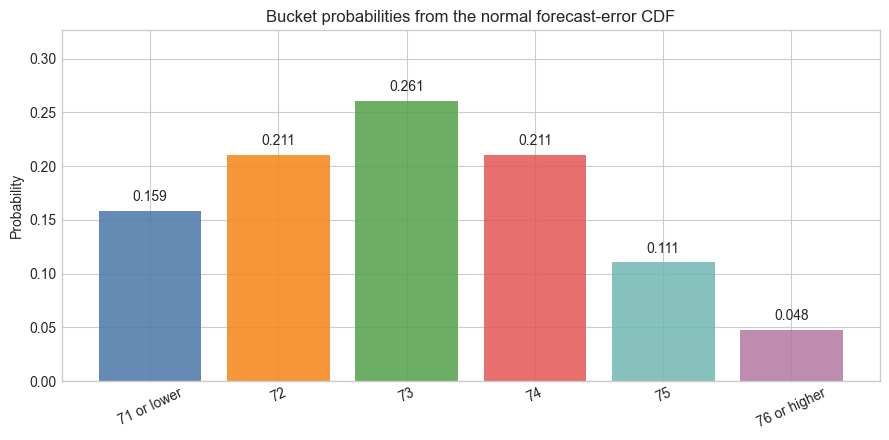

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(priced_df["bucket"], priced_df["probability"], color=colors, alpha=0.86)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f"{height:.3f}", ha="center", va="bottom")

ax.set_ylim(0.0, max(priced_df["probability"]) * 1.25)
ax.set_ylabel("Probability")
ax.set_title("Bucket probabilities from the normal forecast-error CDF")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()

The center bucket, `73`, is highest because the normal distribution is centered at zero forecast error. The `72` and `74` buckets are symmetric around zero error, so they receive nearly identical mass.

## 5. Probability Normalization

`normalize_probabilities` is a small cleanup layer for numerical output from models. It:

- clips tiny negative probabilities caused by floating-point noise,
- refuses large negative probabilities,
- refuses zero or non-finite total mass,
- renormalizes the cleaned values to sum to one.

This is deliberately conservative: tiny numerical dust is cleaned, but a materially non-monotone CDF should fail loudly.

In [11]:
raw_probs = [-1e-12, 0.20, 0.30, 0.50]
clean_probs = normalize_probabilities(raw_probs)

pd.DataFrame(
    {
        "raw_probability": raw_probs,
        "clean_probability": clean_probs,
    }
)

,raw_probability,clean_probability
0,-0.000000,0.000000
1,0.200000,0.200000
2,0.300000,0.300000
3,0.500000,0.500000


In [12]:
try:
    normalize_probabilities([-0.01, 0.50, 0.51])
except ValueError as error:
    print(error)

Probability is negative beyond tolerance: -0.01


## 6. Generated Outputs

The script `scripts/generate_day10_distribution_pricing_outputs.py` regenerates both Day 10 CSV outputs. The notebook calls the same functions below, then reads the files back so the saved artifacts are visible here too.

In [13]:
conversion_output = OUTPUT_DIR / "forecast_error_bucket_conversion_examples.csv"
probability_output = OUTPUT_DIR / "interval_probability_demo.csv"

generate_forecast_error_bucket_conversion_examples(conversion_output)
generate_interval_probability_demo(probability_output)

print(conversion_output)
print(probability_output)

C:\Weather Trading\Kalshi-Weather-Trading\outputs\forecast_error_bucket_conversion_examples.csv
C:\Weather Trading\Kalshi-Weather-Trading\outputs\interval_probability_demo.csv


In [14]:
pd.read_csv(conversion_output)

,bucket,lower_temp,upper_temp,forecast_high,lower_error,upper_error
0,71 or lower,NaN,71.500000,73.000000,NaN,-1.500000
1,72,71.500000,72.500000,73.000000,-1.500000,-0.500000
2,73,72.500000,73.500000,73.000000,-0.500000,0.500000
3,74,73.500000,74.500000,73.000000,0.500000,1.500000
4,75,74.500000,75.500000,73.000000,1.500000,2.500000
5,76 or higher,75.500000,NaN,73.000000,2.500000,NaN


In [15]:
pd.read_csv(probability_output)

,bucket,lower_temp,upper_temp,forecast_high,lower_error,upper_error,probability
0,71 or lower,NaN,71.500000,73.000000,NaN,-1.500000,0.158655
1,72,71.500000,72.500000,73.000000,-1.500000,-0.500000,0.210786
2,73,72.500000,73.500000,73.000000,-0.500000,0.500000,0.261117
3,74,73.500000,74.500000,73.000000,0.500000,1.500000,0.210786
4,75,74.500000,75.500000,73.000000,1.500000,2.500000,0.110865
5,76 or higher,75.500000,NaN,73.000000,2.500000,NaN,0.047790


## 7. Validation Checklist

Day 10 tests cover the main failure modes:

- integer bucket construction produces six buckets for `make_integer_temperature_buckets(71, 76)`,
- first and last buckets are open-ended on the correct side,
- half-degree boundaries are used,
- the forecast_high=73 conversion maps `72` to `(-1.5, -0.5]`, `73` to `(-0.5, 0.5]`, and `76 or higher` to `(2.5, None)`,
- fake CDF interval probabilities match the expected arithmetic,
- normalization clips tiny negatives and rejects large negatives,
- final priced probabilities are nonnegative and sum to one,
- the normal demo gives the center bucket highest probability and similar probabilities to `72` and `74`.

From the repo root, run:

```powershell
python -m pytest tests/test_day10_distribution_pricing.py
python scripts/generate_day10_distribution_pricing_outputs.py
```

In [16]:
checks = {
    "bucket_count": len(buckets),
    "first_bucket": buckets[0].label,
    "first_upper_temp": buckets[0].upper_temp,
    "last_bucket": buckets[-1].label,
    "last_lower_temp": buckets[-1].lower_temp,
    "probability_sum": float(priced_df["probability"].sum()),
    "center_bucket_is_highest": center_bucket == "73",
    "has_negative_probability": bool((priced_df["probability"] < 0).any()),
}

pd.DataFrame([checks])

,bucket_count,first_bucket,first_upper_temp,last_bucket,last_lower_temp,probability_sum,center_bucket_is_highest,has_negative_probability
0,6,71 or lower,71.500000,76 or higher,75.500000,1.000000,True,False


## Mental Model

The Day 10 layer has three clean stages:

1. Build final-temperature settlement buckets with half-degree boundaries.
2. Subtract `forecast_high` from each finite boundary to get forecast-error intervals.
3. Price those intervals with `F(upper_error) - F(lower_error)` from any CDF.

That separation is the useful part. Bucket construction, error conversion, and model-specific distribution estimation can now evolve independently.